In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.inspection import permutation_importance

In [2]:
df = pd.read_csv("../data/processed/wine_processed.csv")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5


In [3]:
X = df.drop("quality", axis=1)
y = df["quality"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (1018, 11)
Target Shape : (1018,)


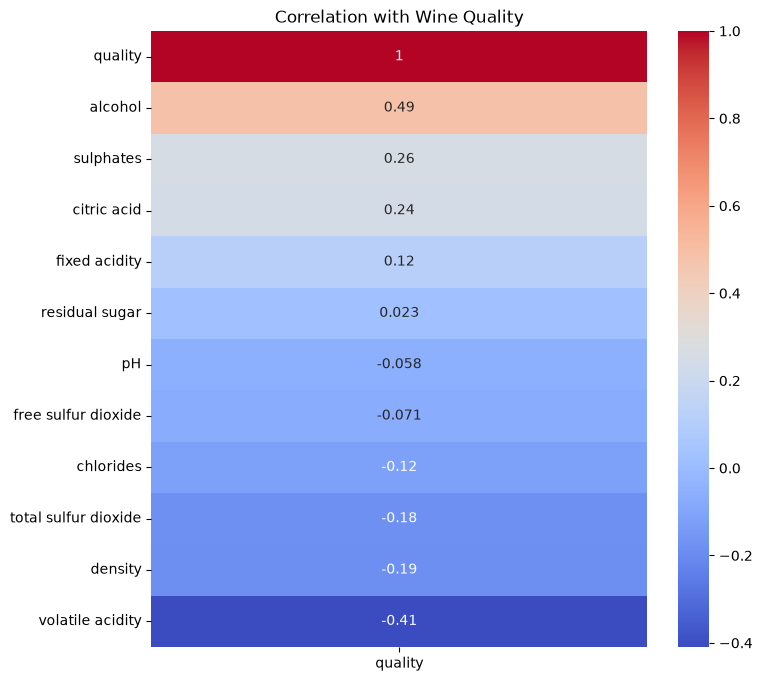

In [4]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(8,8))

sns.heatmap(
    correlation[["quality"]].sort_values(by="quality", ascending=False),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation with Wine Quality")

plt.show()

In [5]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X, y)

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
10,alcohol,0.149565
9,sulphates,0.115239
1,volatile acidity,0.104150
6,total sulfur dioxide,0.101036
7,density,0.086752
4,chlorides,0.080604
8,pH,0.077831
0,fixed acidity,0.074541
2,citric acid,0.073689
3,residual sugar,0.068918


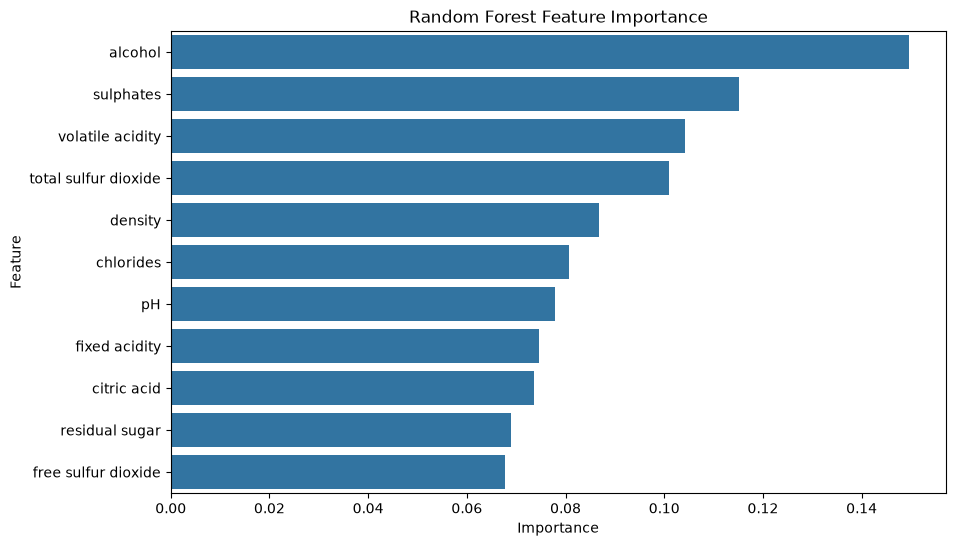

In [6]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.show()

In [7]:
selector = SelectKBest(
    score_func=f_classif,
    k=8
)

selector.fit(X, y)

scores = pd.DataFrame({

    "Feature": X.columns,

    "Score": selector.scores_

})

scores = scores.sort_values(
    by="Score",
    ascending=False
)

scores

,Feature,Score
10,alcohol,75.252188
1,volatile acidity,43.298623
9,sulphates,16.170747
2,citric acid,14.882562
6,total sulfur dioxide,14.334011
7,density,8.669061
0,fixed acidity,3.326035
8,pH,3.278381
4,chlorides,3.239975
5,free sulfur dioxide,2.898068


In [8]:
selected_features = X.columns[selector.get_support()]

print("Selected Features:\n")

for feature in selected_features:
    print(feature)

Selected Features:

fixed acidity
volatile acidity
citric acid
total sulfur dioxide
density
pH
sulphates
alcohol


In [9]:
result = permutation_importance(
    rf,
    X,
    y,
    n_repeats=10,
    random_state=42
)

perm = pd.DataFrame({

    "Feature": X.columns,

    "Importance": result.importances_mean

})

perm = perm.sort_values(
    by="Importance",
    ascending=False
)

perm

,Feature,Importance
10,alcohol,0.237328
9,sulphates,0.169646
1,volatile acidity,0.110904
6,total sulfur dioxide,0.060216
4,chlorides,0.028684
7,density,0.022888
2,citric acid,0.021218
8,pH,0.020727
3,residual sugar,0.015717
5,free sulfur dioxide,0.015619


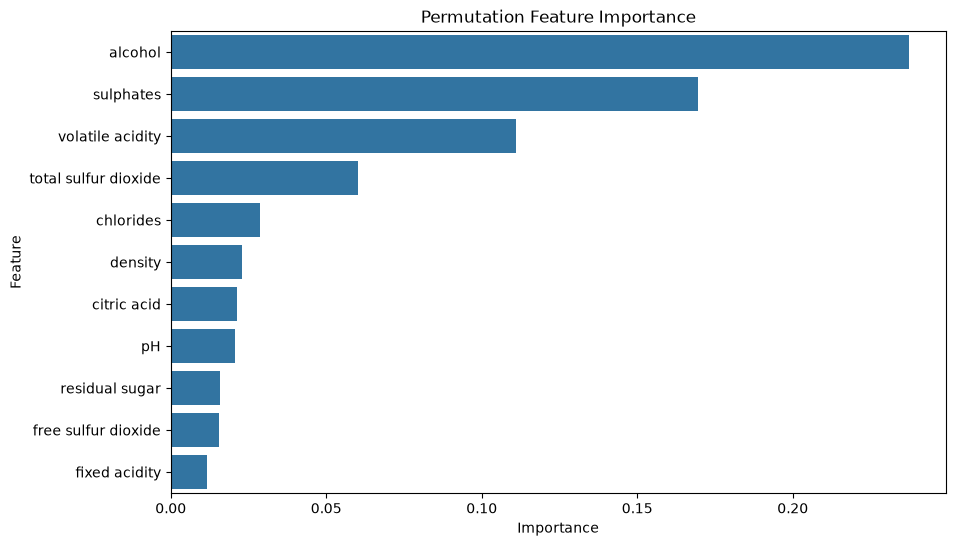

In [10]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=perm,
    x="Importance",
    y="Feature"
)

plt.title("Permutation Feature Importance")

plt.show()

In [11]:
final_features = list(selected_features)

print("Final Features Used")

final_features

Final Features Used


['fixed acidity',
 'volatile acidity',
 'citric acid',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol']

In [12]:
import joblib

joblib.dump(
    final_features,
    "../artifacts/final_features.pkl"
)

print("Feature list saved successfully.")

Feature list saved successfully.
